# 🚒 LFB Greenwich Incident Analysis (2019–2022)

**Student ID:** 4435384 | **Borough:** Greenwich (E09000011) | **Module:** CSI_7_DMA

---

## 📦 Section 1 — Imports, Data Loading & Greenwich Filter

> Loads the full LFB dataset and filters for Greenwich Borough (12,861 incidents)

In [ ]:
# =============================================================
# CSI_7_DMA Coursework — LFB Incident Analysis
# Borough: Greenwich (E09000011)
# Student ID: 
# =============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# --- Plot style ---
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("Set2")

# =============================================================
# TASK 1.1 — Load dataset and filter for Greenwich
# =============================================================

df_all = pd.read_csv('LFB_2019_22.csv', encoding='latin1')
print(f"Full dataset shape: {df_all.shape}")

df = df_all[df_all['IncGeo_BoroughCode'] == 'E09000011'].copy()
df.reset_index(drop=True, inplace=True)

print(f"Greenwich dataset shape: {df.shape}")
print(f"Years covered: {sorted(df['CalYear'].unique())}")
print(f"\nIncident Group distribution:")
print(df['IncidentGroup'].value_counts())
print(f"\nIncident Group % distribution:")
print(df['IncidentGroup'].value_counts(normalize=True).mul(100).round(1))

Full dataset shape: (426461, 39)
Greenwich dataset shape: (12861, 39)
Years covered: [2019, 2020, 2021, 2022]

Incident Group distribution:
IncidentGroup
False Alarm        5198
Special Service    4886
Fire               2777
Name: count, dtype: int64

Incident Group % distribution:
IncidentGroup
False Alarm        40.4
Special Service    38.0
Fire               21.6
Name: proportion, dtype: float64


## 🔧 Section 2 — Data Type Corrections (Task 2.1)

> Correcting data types based on metadata, not pandas defaults

In [5]:
# TASK 2.1 — Correct Data Types
print("=== BEFORE ===")
print(df.dtypes)

df['DateOfCall'] = pd.to_datetime(df['DateOfCall'], dayfirst=True)
df['UPRN'] = df['UPRN'].astype(str)
df['USRN'] = df['USRN'].astype(str)
df['SecondPumpArriving_DeployedFromStation'] = df['SecondPumpArriving_DeployedFromStation'].astype(str)

print("\n=== AFTER ===")
print(df.dtypes)

print("\n=== CORRECTIONS MADE ===")
print("1. DateOfCall: object → datetime64")
print("2. UPRN: int64 → object (identifier, not a quantity)")
print("3. USRN: int64 → object (identifier, not a quantity)")
print("4. SecondPumpArriving_DeployedFromStation: float64 → object (station name, not numeric)")

=== BEFORE ===
IncidentNumber                             object
DateOfCall                                 object
CalYear                                     int64
TimeOfCall                                 object
HourOfCall                                  int64
IncidentGroup                              object
StopCodeDescription                        object
SpecialServiceType                         object
PropertyCategory                           object
PropertyType                               object
AddressQualifier                           object
Postcode_full                              object
Postcode_district                          object
UPRN                                      float64
USRN                                        int64
IncGeo_BoroughCode                         object
IncGeo_BoroughName                         object
ProperCase                                 object
IncGeo_WardCode                            object
IncGeo_WardName                    

## 🛠️ Section 3 — Feature Engineering

> Extracting DayOfWeek, Month, and DayOfWeek_num from DateOfCall

In [6]:
# =============================================================
# FEATURE ENGINEERING — extract temporal features from DateOfCall
# (needed for business problems and EDA)
# =============================================================

df['DayOfWeek'] = df['DateOfCall'].dt.day_name()
df['Month'] = df['DateOfCall'].dt.month
df['DayOfWeek_num'] = df['DateOfCall'].dt.dayofweek  # 0=Monday, 6=Sunday

print("New features added: DayOfWeek, Month, DayOfWeek_num")
print(f"\nDayOfWeek distribution:")
print(df['DayOfWeek'].value_counts())

New features added: DayOfWeek, Month, DayOfWeek_num

DayOfWeek distribution:
DayOfWeek
Saturday     1958
Friday       1878
Sunday       1857
Monday       1843
Tuesday      1793
Wednesday    1786
Thursday     1746
Name: count, dtype: int64


## 📊 Section 4 — Descriptive Statistics (Task 2.2)

> Overview statistics including skewness and kurtosis for all numeric variables

In [7]:
# =============================================================
# TASK 2.2 — Initial Data Exploration
# =============================================================

print(f"Total variables (columns): {df.shape[1]}")
print(f"Total instances (rows): {df.shape[0]}")
print()
print("=== DESCRIPTIVE STATISTICS — Numeric Variables ===")
numeric_cols = ['HourOfCall', 'FirstPumpArriving_AttendanceTime',
                'SecondPumpArriving_AttendanceTime',
                'NumStationsWithPumpsAttending', 'NumPumpsAttending',
                'PumpCount', 'PumpHoursRoundUp', 'Notional Cost (£)', 'NumCalls']

desc = df[numeric_cols].describe().T
desc['skewness'] = df[numeric_cols].skew()
desc['kurtosis'] = df[numeric_cols].kurt()
print(desc.round(3).to_string())

Total variables (columns): 42
Total instances (rows): 12861

=== DESCRIPTIVE STATISTICS — Numeric Variables ===
                                     count     mean       std    min    25%    50%    75%       max  skewness  kurtosis
HourOfCall                         12861.0   13.496     6.273    0.0    9.0   14.0   19.0      23.0    -0.498    -0.644
FirstPumpArriving_AttendanceTime   12196.0  313.006   135.623    1.0  230.0  298.0  372.0    1181.0     1.406     5.011
SecondPumpArriving_AttendanceTime   4458.0  380.919   149.340    1.0  288.0  357.0  444.0    1200.0     1.398     3.667
NumStationsWithPumpsAttending      12776.0    1.318     0.726    1.0    1.0    1.0    1.0       8.0     3.014    10.553
NumPumpsAttending                  12776.0    1.521     0.905    1.0    1.0    1.0    2.0       8.0     2.465     6.892
PumpCount                          12784.0    1.579     1.431    1.0    1.0    1.0    2.0     105.0    32.363  2174.970
PumpHoursRoundUp                   12782.0    1.

## 📈 Section 5 — EDA Plots (Figures 2–7)

> Exploratory Data Analysis — incident distribution, yearly trends, hourly patterns, property categories, attendance time

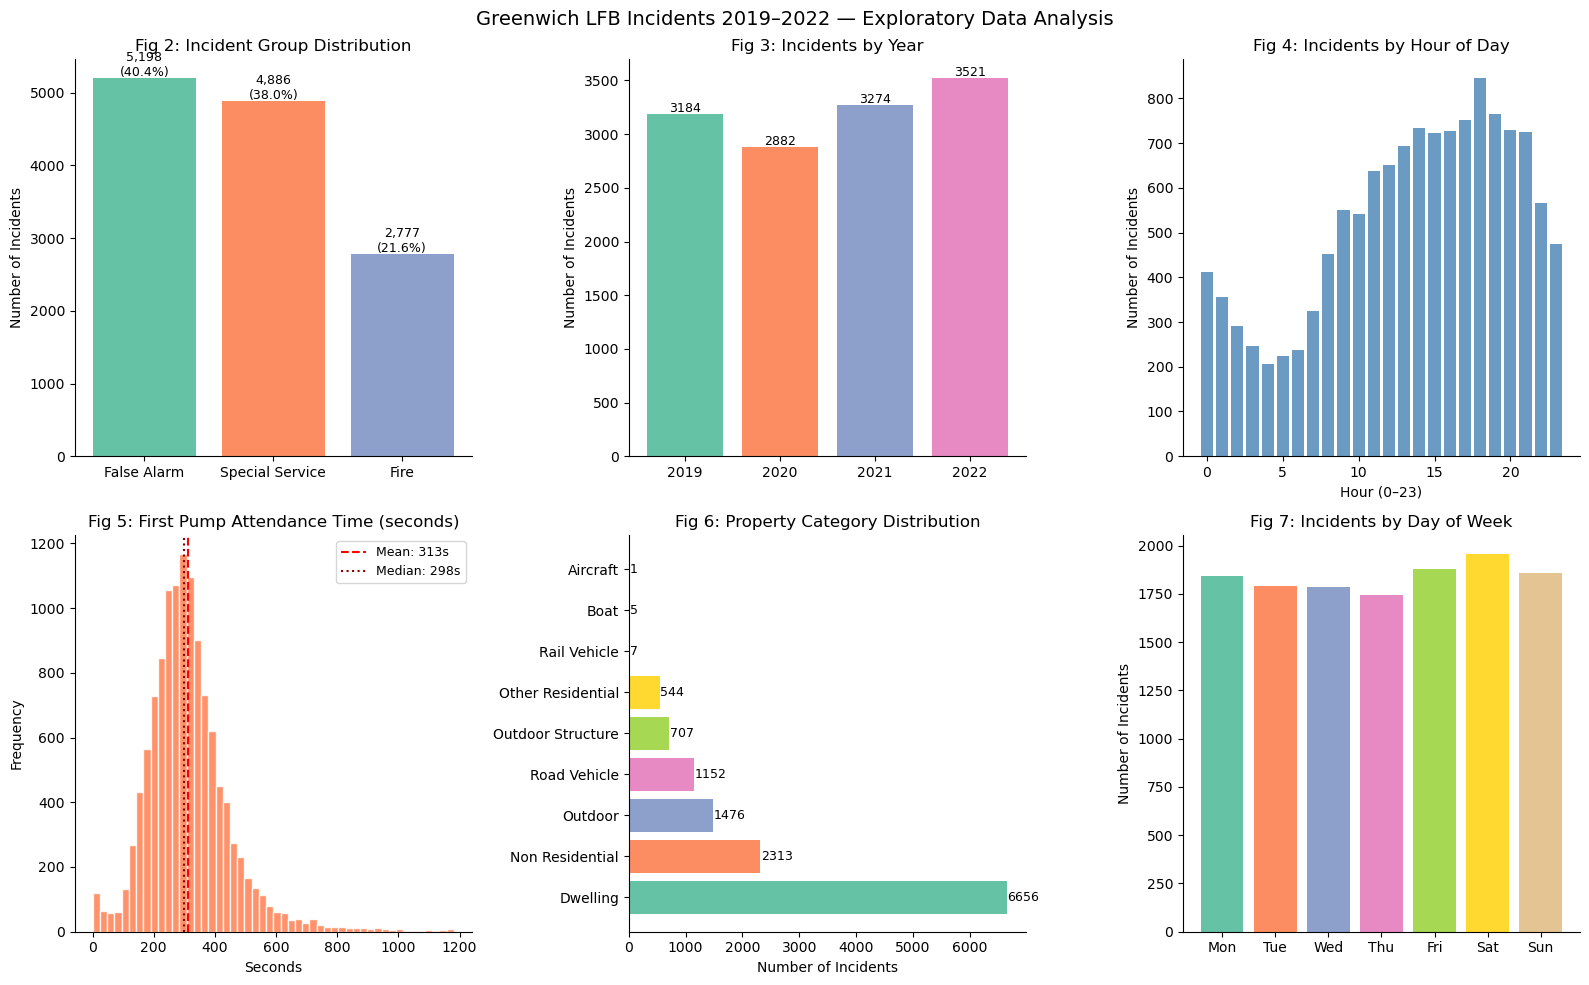

Saved: fig_eda_overview.png


In [41]:
# =============================================================
# EDA PLOTS
# =============================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Greenwich LFB Incidents 2019–2022 — Exploratory Data Analysis', fontsize=14)

# Plot 1: Incident Group distribution
ax = axes[0, 0]
counts = df['IncidentGroup'].value_counts()
bars = ax.bar(counts.index, counts.values, color=sns.color_palette("Set2", 3))
ax.set_title('Fig 2: Incident Group Distribution')
ax.set_ylabel('Number of Incidents')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=9)

# Plot 2: Incidents by Year
ax = axes[0, 1]
year_counts = df['CalYear'].value_counts().sort_index()
ax.bar(year_counts.index.astype(str), year_counts.values, color=sns.color_palette("Set2", 4))
ax.set_title('Fig 3: Incidents by Year')
ax.set_ylabel('Number of Incidents')
for i, (yr, val) in enumerate(year_counts.items()):
    ax.text(i, val + 20, str(val), ha='center', fontsize=9)

# Plot 3: Incidents by Hour of Call
ax = axes[0, 2]
hour_counts = df['HourOfCall'].value_counts().sort_index()
ax.bar(hour_counts.index, hour_counts.values, color='steelblue', alpha=0.8)
ax.set_title('Fig 4: Incidents by Hour of Day')
ax.set_xlabel('Hour (0–23)')
ax.set_ylabel('Number of Incidents')

# Plot 4: First Pump Attendance Time distribution
ax = axes[1, 0]
valid_att = df['FirstPumpArriving_AttendanceTime'].dropna()
ax.hist(valid_att, bins=50, color='coral', edgecolor='white', alpha=0.85)
ax.axvline(valid_att.mean(), color='red', linestyle='--', label=f'Mean: {valid_att.mean():.0f}s')
ax.axvline(valid_att.median(), color='darkred', linestyle=':', label=f'Median: {valid_att.median():.0f}s')
ax.set_title('Fig 5: First Pump Attendance Time (seconds)')
ax.set_xlabel('Seconds')
ax.set_ylabel('Frequency')
ax.legend(fontsize=9)

# Plot 5: Property Category
ax = axes[1, 1]
prop_counts = df['PropertyCategory'].value_counts()
ax.barh(prop_counts.index, prop_counts.values, color=sns.color_palette("Set2", len(prop_counts)))
ax.set_title('Fig 6: Property Category Distribution')
ax.set_xlabel('Number of Incidents')
for i, val in enumerate(prop_counts.values):
    ax.text(val + 10, i, str(val), va='center', fontsize=9)

# Plot 6: Incidents by Day of Week
ax = axes[1, 2]
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_counts = df['DayOfWeek'].value_counts().reindex(day_order)
ax.bar(range(7), day_counts.values, color=sns.color_palette("Set2", 7))
ax.set_xticks(range(7))
ax.set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
ax.set_title('Fig 7: Incidents by Day of Week')
ax.set_ylabel('Number of Incidents')

plt.tight_layout()
plt.savefig('fig_eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_eda_overview.png")

## 🔍 Section 6 — Data Quality Issues (Task 2.3)

> Detecting missing values, outliers, class imbalance, and incomparable value ranges

In [9]:
# =============================================================
# TASK 2.3 — Data Quality Issues
# =============================================================

print("=" * 60)
print("1. MISSING VALUES — by variable")
print("=" * 60)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
print(missing_df.to_string())

print("\n" + "=" * 60)
print("2. EXPLANATION OF MISSING VALUE PATTERNS")
print("=" * 60)
print(f"\nSpecialServiceType missing: {df['SpecialServiceType'].isnull().sum()}")
print("  → Expected: only rows where IncidentGroup = 'Special Service' should have a value")
special_check = df.groupby('IncidentGroup')['SpecialServiceType'].apply(lambda x: x.notnull().sum())
print(f"  SpecialServiceType populated per group:\n{special_check}")

print(f"\nPostcode/Location fields missing: {df['Postcode_full'].isnull().sum()}")
print("  → Expected: redacted for Dwelling property type (privacy policy)")
postcode_by_prop = df[df['Postcode_full'].isnull()]['PropertyCategory'].value_counts()
print(f"  Missing postcode by PropertyCategory:\n{postcode_by_prop}")

print(f"\nSecondPump fields missing: {df['SecondPumpArriving_AttendanceTime'].isnull().sum()}")
print("  → Expected: only incidents requiring 2+ pumps will have a second pump record")
second_pump_check = df[df['SecondPumpArriving_AttendanceTime'].notnull()]['NumPumpsAttending'].value_counts()
print(f"  NumPumpsAttending where SecondPump is populated:\n{second_pump_check}")

print("\n" + "=" * 60)
print("3. OUTLIERS — Attendance Time")
print("=" * 60)
att = df['FirstPumpArriving_AttendanceTime'].dropna()
Q1, Q3 = att.quantile(0.25), att.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = att[(att < lower_bound) | (att > upper_bound)]
print(f"Q1={Q1:.0f}s, Q3={Q3:.0f}s, IQR={IQR:.0f}s")
print(f"Lower fence: {lower_bound:.0f}s, Upper fence: {upper_bound:.0f}s")
print(f"Outliers detected: {len(outliers)} ({len(outliers)/len(att)*100:.1f}% of non-null values)")
print(f"Min outlier: {outliers.min():.0f}s, Max outlier: {outliers.max():.0f}s")

print("\n" + "=" * 60)
print("4. OUTLIERS — Notional Cost")
print("=" * 60)
cost = df['Notional Cost (£)'].dropna()
Q1c, Q3c = cost.quantile(0.25), cost.quantile(0.75)
IQRc = Q3c - Q1c
upper_cost = Q3c + 1.5 * IQRc
cost_outliers = cost[cost > upper_cost]
print(f"Q1=£{Q1c:.0f}, Q3=£{Q3c:.0f}, IQR=£{IQRc:.0f}")
print(f"Upper fence: £{upper_cost:.0f}")
print(f"Cost outliers above fence: {len(cost_outliers)} ({len(cost_outliers)/len(cost)*100:.1f}%)")
print(f"Max cost: £{cost.max():,.0f}")

print("\n" + "=" * 60)
print("5. IMBALANCED CLASSES — IncidentGroup")
print("=" * 60)
class_dist = df['IncidentGroup'].value_counts()
print(class_dist)
print(f"Imbalance ratio (largest/smallest): {class_dist.max()/class_dist.min():.2f}x")

print("\n" + "=" * 60)
print("6. INCOMPARABLE VALUE RANGES — numeric variables")
print("=" * 60)
range_check = df[['FirstPumpArriving_AttendanceTime', 'NumPumpsAttending',
                   'PumpHoursRoundUp', 'Notional Cost (£)', 'NumCalls']].describe().loc[['min','max','mean','std']]
print(range_check.round(2).to_string())
print("\n→ Notional Cost (£) range (~£333–£176,176) is far larger than NumPumpsAttending (1–15)")
print("→ Normalisation/standardisation required before any distance-based model (e.g. K-Means)")

1. MISSING VALUES — by variable
                                       Missing Count  Missing %
SecondPumpArriving_AttendanceTime               8403      65.34
SpecialServiceType                              7975      62.01
Postcode_full                                   6725      52.29
Easting_m                                       6725      52.29
Northing_m                                      6725      52.29
Latitude                                        6725      52.29
Longitude                                       6725      52.29
FirstPumpArriving_AttendanceTime                 665       5.17
FirstPumpArriving_DeployedFromStation            665       5.17
NumStationsWithPumpsAttending                     85       0.66
NumPumpsAttending                                 85       0.66
PumpHoursRoundUp                                  79       0.61
Notional Cost (£)                                 79       0.61
PumpCount                                         77       0.60

2. EXPL

## 📦 Section 7 — Outlier Visualisation (Figure 8)

> Boxplots confirming outliers using IQR method

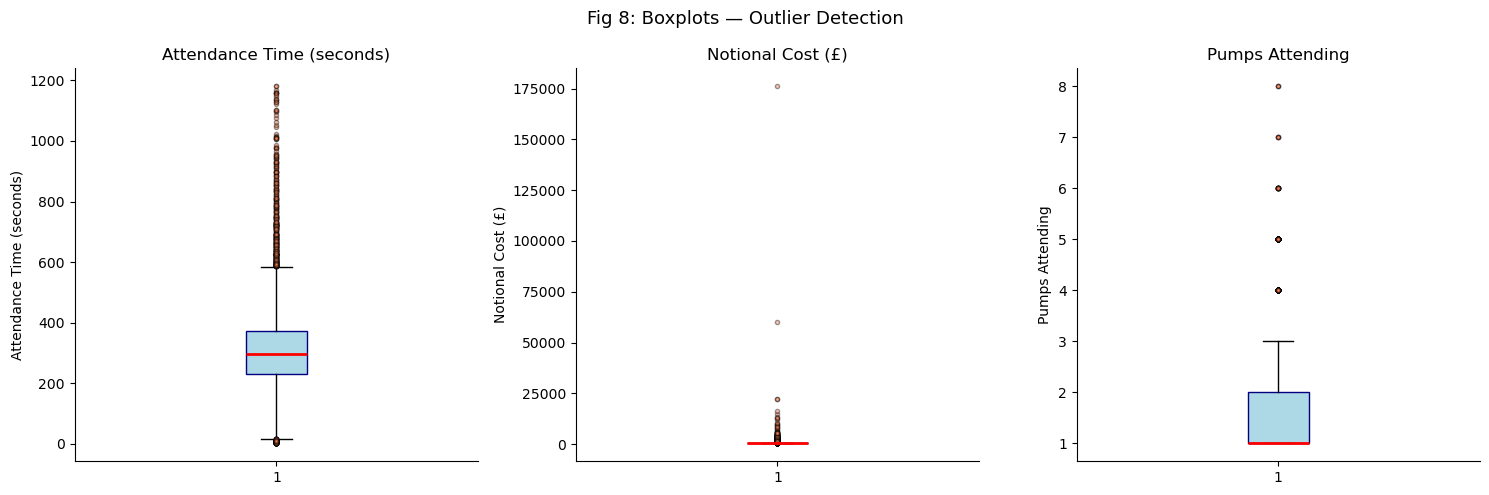

Saved: fig_outliers.png


In [42]:
# =============================================================
# OUTLIER VISUALISATION
# =============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Fig 8: Boxplots — Outlier Detection', fontsize=13)

for ax, col, label in zip(axes,
    ['FirstPumpArriving_AttendanceTime', 'Notional Cost (£)', 'NumPumpsAttending'],
    ['Attendance Time (seconds)', 'Notional Cost (£)', 'Pumps Attending']):
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='lightblue', color='navy'),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='o', markerfacecolor='coral', markersize=3, alpha=0.4))
    ax.set_title(label)
    ax.set_ylabel(label)

plt.tight_layout()
plt.savefig('fig_outliers.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_outliers.png")

---

## 🧹 Section 8 — Data Preparation (Task 3)

### 3.1 Variable Selection

> Dropping irrelevant, duplicate, and high-missingness columns

In [11]:
# =============================================================
# TASK 3 — Data Preparation
# =============================================================

# --- 3.1 Select working dataframe ---
# We make a clean copy to preserve the original
df_clean = df.copy()
print(f"Starting rows: {len(df_clean)}")

# =============================================================
# 3.2a — Drop irrelevant/identifier columns
# =============================================================
drop_cols = [
    'IncidentNumber',        # unique identifier, no predictive value
    'Postcode_full',         # 52% missing, redacted for dwellings
    'Postcode_district',     # too granular, ward already captures location
    'UPRN', 'USRN',          # property identifiers
    'ProperCase',            # duplicate of IncGeo_BoroughName
    'IncGeo_BoroughCode',    # constant (all Greenwich)
    'IncGeo_BoroughName',    # constant (all Greenwich)
    'FRS',                   # constant (all London)
    'Easting_m', 'Northing_m',   # 52% missing, rounded versions retained
    'Latitude', 'Longitude',     # 52% missing, rounded versions retained
    'IncGeo_WardNameNew',    # duplicate of IncGeo_WardName
    'SecondPumpArriving_AttendanceTime',       # 65% missing
    'SecondPumpArriving_DeployedFromStation',  # 65% missing
    'TimeOfCall',            # HourOfCall already extracted
    'DayOfWeek',             # DayOfWeek_num retained (numeric)
    'Month',                 # not used in any business problem
]

df_clean.drop(columns=drop_cols, inplace=True)
print(f"Columns after dropping irrelevant variables: {df_clean.shape[1]}")
print(f"Remaining columns: {df_clean.columns.tolist()}")

Starting rows: 12861
Columns after dropping irrelevant variables: 23
Remaining columns: ['DateOfCall', 'CalYear', 'HourOfCall', 'IncidentGroup', 'StopCodeDescription', 'SpecialServiceType', 'PropertyCategory', 'PropertyType', 'AddressQualifier', 'IncGeo_WardCode', 'IncGeo_WardName', 'Easting_rounded', 'Northing_rounded', 'IncidentStationGround', 'FirstPumpArriving_AttendanceTime', 'FirstPumpArriving_DeployedFromStation', 'NumStationsWithPumpsAttending', 'NumPumpsAttending', 'PumpCount', 'PumpHoursRoundUp', 'Notional Cost (£)', 'NumCalls', 'DayOfWeek_num']


### 3.2 Handling Missing Values

> Removing genuine missing rows and filling structural missing values

In [12]:
# =============================================================
# 3.2b — Handle missing values
# =============================================================

print("Missing values BEFORE handling:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

# FirstPumpArriving_AttendanceTime: 5.17% missing
# → Drop these rows (small %, and attendance time is target for BP2)
before = len(df_clean)
df_clean.dropna(subset=['FirstPumpArriving_AttendanceTime'], inplace=True)
print(f"\nRows dropped (missing attendance time): {before - len(df_clean)}")
print(f"Rows remaining: {len(df_clean)}")

# FirstPumpArriving_DeployedFromStation: same rows, already dropped above
# NumStationsWithPumpsAttending, NumPumpsAttending: 0.66% missing → drop
before = len(df_clean)
df_clean.dropna(subset=['NumStationsWithPumpsAttending', 'NumPumpsAttending'], inplace=True)
print(f"Rows dropped (missing pump counts): {before - len(df_clean)}")
print(f"Rows remaining: {len(df_clean)}")

# PumpHoursRoundUp, Notional Cost, PumpCount: 0.6% missing → drop
before = len(df_clean)
df_clean.dropna(subset=['PumpHoursRoundUp', 'Notional Cost (£)', 'PumpCount'], inplace=True)
print(f"Rows dropped (missing pump hours/cost): {before - len(df_clean)}")
print(f"Rows remaining: {len(df_clean)}")

# SpecialServiceType: 62% missing — structural (only special services have it)
# → Fill with 'Not Applicable' for non-special-service incidents
df_clean['SpecialServiceType'].fillna('Not Applicable', inplace=True)

print("\nMissing values AFTER handling:")
remaining = df_clean.isnull().sum()[df_clean.isnull().sum() > 0]
print(remaining if len(remaining) > 0 else "No missing values remaining")

Missing values BEFORE handling:
SpecialServiceType                       7975
FirstPumpArriving_AttendanceTime          665
FirstPumpArriving_DeployedFromStation     665
NumStationsWithPumpsAttending              85
NumPumpsAttending                          85
PumpCount                                  77
PumpHoursRoundUp                           79
Notional Cost (£)                          79
dtype: int64

Rows dropped (missing attendance time): 665
Rows remaining: 12196
Rows dropped (missing pump counts): 0
Rows remaining: 12196
Rows dropped (missing pump hours/cost): 0
Rows remaining: 12196

Missing values AFTER handling:
No missing values remaining


### 3.3 Outlier Treatment (Winsorisation)

> Capping extreme values to preserve row count

In [13]:
# =============================================================
# 3.2c — Handle outliers
# =============================================================

# Attendance Time: cap at IQR upper fence (585s) — retain but cap extreme values
att_upper = 585
before_count = len(df_clean)
outlier_count = (df_clean['FirstPumpArriving_AttendanceTime'] > att_upper).sum()
df_clean['FirstPumpArriving_AttendanceTime'] = df_clean['FirstPumpArriving_AttendanceTime'].clip(upper=att_upper)
print(f"Attendance time: {outlier_count} values capped at {att_upper}s")

# Also cap suspiciously low values (< 60s = likely data error)
low_count = (df_clean['FirstPumpArriving_AttendanceTime'] < 60).sum()
df_clean['FirstPumpArriving_AttendanceTime'] = df_clean['FirstPumpArriving_AttendanceTime'].clip(lower=60)
print(f"Attendance time: {low_count} suspiciously low values (<60s) capped at 60s")

# Notional Cost: cap at 99th percentile (extreme outliers distort clustering)
cost_cap = df_clean['Notional Cost (£)'].quantile(0.99)
cost_outliers = (df_clean['Notional Cost (£)'] > cost_cap).sum()
df_clean['Notional Cost (£)'] = df_clean['Notional Cost (£)'].clip(upper=cost_cap)
print(f"Notional Cost: {cost_outliers} values capped at 99th percentile (£{cost_cap:.0f})")

# PumpCount: cap at 99th percentile (max of 105 is clearly anomalous)
pump_cap = df_clean['PumpCount'].quantile(0.99)
pump_outliers = (df_clean['PumpCount'] > pump_cap).sum()
df_clean['PumpCount'] = df_clean['PumpCount'].clip(upper=pump_cap)
print(f"PumpCount: {pump_outliers} values capped at 99th percentile ({pump_cap:.0f})")

print(f"\nRows remaining after outlier handling: {len(df_clean)}")

Attendance time: 447 values capped at 585s
Attendance time: 212 suspiciously low values (<60s) capped at 60s
Notional Cost: 117 values capped at 99th percentile (£2422)
PumpCount: 85 values capped at 99th percentile (5)

Rows remaining after outlier handling: 12196


### 3.4 Data Type Corrections

> Casting float64 columns to int32 after missing value removal

In [14]:
# =============================================================
# 3.2d — Fix remaining float columns that should be int
# (safe to cast now that missing values are dropped)
# =============================================================

int_cols = ['NumStationsWithPumpsAttending', 'NumPumpsAttending',
            'PumpCount', 'PumpHoursRoundUp', 'NumCalls']
for col in int_cols:
    df_clean[col] = df_clean[col].astype(int)

print("Cast to int:", int_cols)
print(df_clean[int_cols].dtypes)

Cast to int: ['NumStationsWithPumpsAttending', 'NumPumpsAttending', 'PumpCount', 'PumpHoursRoundUp', 'NumCalls']
NumStationsWithPumpsAttending    int32
NumPumpsAttending                int32
PumpCount                        int32
PumpHoursRoundUp                 int32
NumCalls                         int32
dtype: object


### 3.5 Encoding Categorical Variables

> Label encoding target variable and one-hot encoding PropertyCategory

In [15]:
# =============================================================
# 3.2e — Encode categorical variables
# =============================================================

from sklearn.preprocessing import LabelEncoder

# Label encode the target variable for BP1 (classification)
le = LabelEncoder()
df_clean['IncidentGroup_encoded'] = le.fit_transform(df_clean['IncidentGroup'])
print("IncidentGroup encoding:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} = {cls}")

# One-hot encode PropertyCategory (used in BP1 and BP2)
df_clean = pd.get_dummies(df_clean, columns=['PropertyCategory'], prefix='PropCat', drop_first=False)
print(f"\nAfter one-hot encoding PropertyCategory:")
prop_cols = [c for c in df_clean.columns if c.startswith('PropCat')]
print(f"New columns: {prop_cols}")

print(f"\nFinal dataset shape: {df_clean.shape}")

IncidentGroup encoding:
  0 = False Alarm
  1 = Fire
  2 = Special Service

After one-hot encoding PropertyCategory:
New columns: ['PropCat_Aircraft', 'PropCat_Boat', 'PropCat_Dwelling', 'PropCat_Non Residential', 'PropCat_Other Residential', 'PropCat_Outdoor', 'PropCat_Outdoor Structure', 'PropCat_Rail Vehicle', 'PropCat_Road Vehicle']

Final dataset shape: (12196, 32)


### 3.6 Normalisation

> StandardScaler applied to clustering features to ensure equal contribution

In [16]:
# =============================================================
# 3.2f — Normalisation for clustering (BP3)
# =============================================================

from sklearn.preprocessing import StandardScaler

cluster_features = ['NumPumpsAttending', 'PumpHoursRoundUp',
                    'Notional Cost (£)', 'NumCalls']

scaler = StandardScaler()
df_cluster = df_clean[cluster_features].copy()
df_cluster_scaled = pd.DataFrame(
    scaler.fit_transform(df_cluster),
    columns=cluster_features
)

print("Cluster features — BEFORE scaling:")
print(df_clean[cluster_features].describe().loc[['mean','std','min','max']].round(2))
print("\nCluster features — AFTER scaling (StandardScaler):")
print(df_cluster_scaled.describe().loc[['mean','std','min','max']].round(3))

Cluster features — BEFORE scaling:
      NumPumpsAttending  PumpHoursRoundUp  Notional Cost (£)  NumCalls
mean               1.55              1.41             449.30      1.37
std                0.92              4.93             304.55      1.56
min                1.00              1.00             333.00      1.00
max                8.00            484.00            2422.00     48.00

Cluster features — AFTER scaling (StandardScaler):
      NumPumpsAttending  PumpHoursRoundUp  Notional Cost (£)  NumCalls
mean              0.000             0.000             -0.000    -0.000
std               1.000             1.000              1.000     1.000
min              -0.594            -0.083             -0.382    -0.240
max               7.028            97.795              6.478    29.982


### 3.7 Train/Test Split

> 80/20 stratified split for BP1 and BP2

In [20]:
# =============================================================

# 3.2g — Train/test split for predictive models (BP1 + BP2)

# =============================================================

from sklearn.model_selection import train_test_split

# BP1 — Classification features
bp1_features = ['HourOfCall', 'DayOfWeek_num', 'CalYear', 'NumCalls'] + \
               [c for c in df_clean.columns if c.startswith('PropCat')]
X_bp1 = df_clean[bp1_features]
y_bp1 = df_clean['IncidentGroup_encoded']

X_train_bp1, X_test_bp1, y_train_bp1, y_test_bp1 = train_test_split(
    X_bp1, y_bp1, test_size=0.2, random_state=42, stratify=y_bp1)

print(f"BP1 — Classification split:")
print(f"  Training set: {X_train_bp1.shape[0]} rows")
print(f"  Test set:     {X_test_bp1.shape[0]} rows")

# BP2 — Regression features
bp2_features = ['HourOfCall', 'DayOfWeek_num', 'NumCalls',
                'NumPumpsAttending', 'NumStationsWithPumpsAttending'] + \
               [c for c in df_clean.columns if c.startswith('PropCat')]
X_bp2 = df_clean[bp2_features]
y_bp2 = df_clean['FirstPumpArriving_AttendanceTime']

X_train_bp2, X_test_bp2, y_train_bp2, y_test_bp2 = train_test_split(
    X_bp2, y_bp2, test_size=0.2, random_state=42)

print(f"\nBP2 — Regression split:")
print(f"  Training set: {X_train_bp2.shape[0]} rows")
print(f"  Test set:     {X_test_bp2.shape[0]} rows")

BP1 — Classification split:
  Training set: 9756 rows
  Test set:     2440 rows

BP2 — Regression split:
  Training set: 9756 rows
  Test set:     2440 rows


---

## 🤖 Section 9 — Model Construction (Task 4)

### BP1 — Incident Type Classification

#### Decision Tree Classifier

In [21]:
# =============================================================
# TASK 4 — MODEL CONSTRUCTION
# BP1: Decision Tree Classifier + Logistic Regression
# =============================================================

from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

# --- BP1a: Decision Tree Classifier ---
dt_bp1 = DecisionTreeClassifier(max_depth=5, min_samples_leaf=50, random_state=42)
dt_bp1.fit(X_train_bp1, y_train_bp1)
y_pred_dt_bp1 = dt_bp1.predict(X_test_bp1)

print("=== BP1: Decision Tree Classifier ===")
print(f"Train accuracy: {dt_bp1.score(X_train_bp1, y_train_bp1):.4f}")
print(f"Test accuracy:  {accuracy_score(y_test_bp1, y_pred_dt_bp1):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_bp1, y_pred_dt_bp1,
      target_names=le.classes_))

=== BP1: Decision Tree Classifier ===
Train accuracy: 0.6238
Test accuracy:  0.5852

Classification Report:
                 precision    recall  f1-score   support

    False Alarm       0.58      0.65      0.61      1033
           Fire       0.66      0.58      0.62       551
Special Service       0.55      0.51      0.53       856

       accuracy                           0.59      2440
      macro avg       0.59      0.58      0.59      2440
   weighted avg       0.59      0.59      0.58      2440



#### Logistic Regression

In [22]:
# --- BP1b: Logistic Regression ---
lr_bp1 = LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial')
lr_bp1.fit(X_train_bp1, y_train_bp1)
y_pred_lr_bp1 = lr_bp1.predict(X_test_bp1)

print("=== BP1: Logistic Regression ===")
print(f"Train accuracy: {lr_bp1.score(X_train_bp1, y_train_bp1):.4f}")
print(f"Test accuracy:  {accuracy_score(y_test_bp1, y_pred_lr_bp1):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_bp1, y_pred_lr_bp1,
      target_names=le.classes_))

=== BP1: Logistic Regression ===
Train accuracy: 0.6073
Test accuracy:  0.5762

Classification Report:
                 precision    recall  f1-score   support

    False Alarm       0.61      0.56      0.58      1033
           Fire       0.65      0.60      0.62       551
Special Service       0.51      0.58      0.54       856

       accuracy                           0.58      2440
      macro avg       0.59      0.58      0.58      2440
   weighted avg       0.58      0.58      0.58      2440



#### Confusion Matrices (Figure 12)

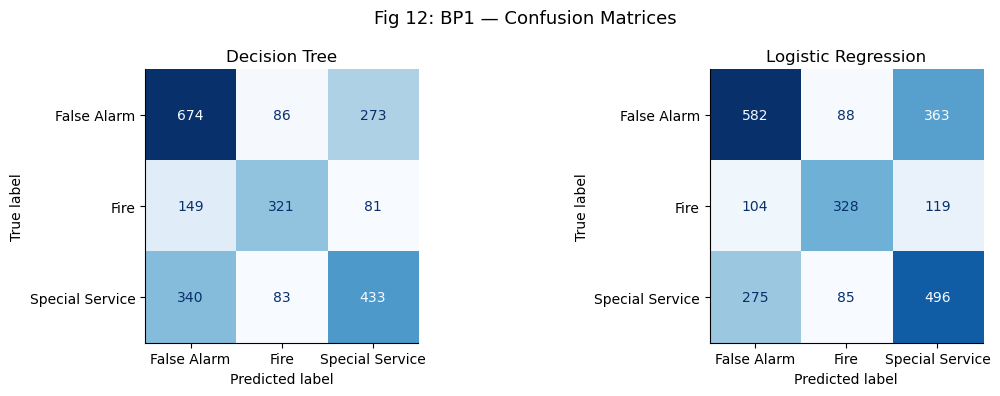

In [45]:
# --- Confusion matrices side by side ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Fig 12: BP1 — Confusion Matrices', fontsize=13)

for ax, y_pred, title in zip(axes,
    [y_pred_dt_bp1, y_pred_lr_bp1],
    ['Decision Tree', 'Logistic Regression']):
    cm = confusion_matrix(y_test_bp1, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title)

plt.tight_layout()
plt.savefig('fig_bp1_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

### BP2 — Attendance Time Prediction

#### Decision Tree Regressor

In [24]:
# =============================================================
# BP2: Decision Tree Regressor + Linear Regression
# =============================================================

from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- BP2a: Decision Tree Regressor ---
dt_bp2 = DecisionTreeRegressor(max_depth=5, min_samples_leaf=50, random_state=42)
dt_bp2.fit(X_train_bp2, y_train_bp2)
y_pred_dt_bp2 = dt_bp2.predict(X_test_bp2)

print("=== BP2: Decision Tree Regressor ===")
print(f"Train R²: {dt_bp2.score(X_train_bp2, y_train_bp2):.4f}")
print(f"Test  R²: {r2_score(y_test_bp2, y_pred_dt_bp2):.4f}")
print(f"Test MAE: {mean_absolute_error(y_test_bp2, y_pred_dt_bp2):.2f}s")
print(f"Test RMSE: {mean_squared_error(y_test_bp2, y_pred_dt_bp2, squared=False):.2f}s")

=== BP2: Decision Tree Regressor ===
Train R²: 0.0424
Test  R²: 0.0278
Test MAE: 88.88s
Test RMSE: 113.59s


#### Linear Regression

In [25]:
# --- BP2b: Linear Regression ---
lr_bp2 = LinearRegression()
lr_bp2.fit(X_train_bp2, y_train_bp2)
y_pred_lr_bp2 = lr_bp2.predict(X_test_bp2)

print("=== BP2: Linear Regression ===")
print(f"Train R²: {lr_bp2.score(X_train_bp2, y_train_bp2):.4f}")
print(f"Test  R²: {r2_score(y_test_bp2, y_pred_lr_bp2):.4f}")
print(f"Test MAE: {mean_absolute_error(y_test_bp2, y_pred_lr_bp2):.2f}s")
print(f"Test RMSE: {mean_squared_error(y_test_bp2, y_pred_lr_bp2, squared=False):.2f}s")

print(f"\n=== Linear Regression Equation ===")
print(f"Intercept: {lr_bp2.intercept_:.4f}")
print("\nCoefficients:")
for feat, coef in zip(bp2_features, lr_bp2.coef_):
    print(f"  {feat}: {coef:.4f}")

=== BP2: Linear Regression ===
Train R²: 0.0286
Test  R²: 0.0246
Test MAE: 89.45s
Test RMSE: 113.77s

=== Linear Regression Equation ===
Intercept: 353.0895

Coefficients:
  HourOfCall: -1.2716
  DayOfWeek_num: 0.0681
  NumCalls: 4.0312
  NumPumpsAttending: -23.9856
  NumStationsWithPumpsAttending: 23.4338
  PropCat_Aircraft: 180.5755
  PropCat_Boat: -0.3044
  PropCat_Dwelling: -22.9942
  PropCat_Non Residential: -48.0331
  PropCat_Other Residential: -60.8168
  PropCat_Outdoor: -8.6891
  PropCat_Outdoor Structure: -22.4813
  PropCat_Rail Vehicle: 9.9671
  PropCat_Road Vehicle: -27.2237


#### Actual vs Predicted Plot (Figure 13)

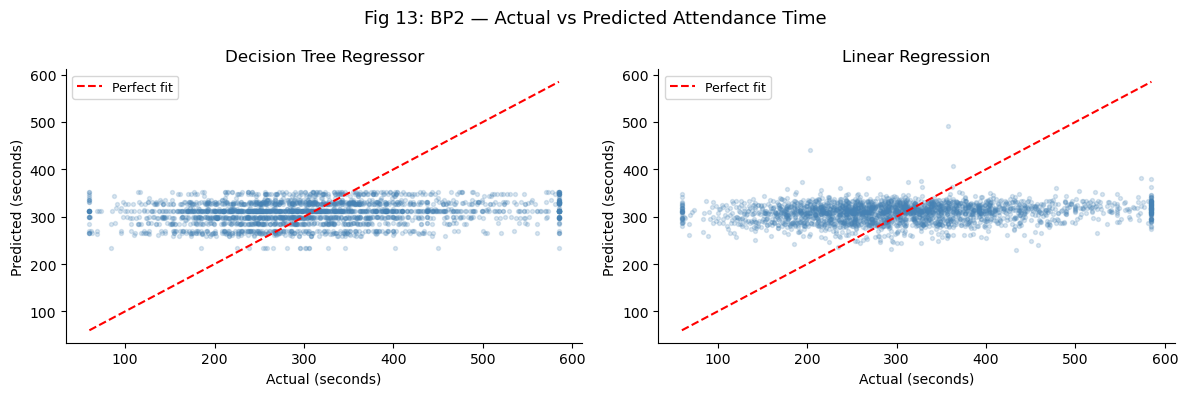

In [46]:
# --- Actual vs Predicted plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Fig 13: BP2 — Actual vs Predicted Attendance Time', fontsize=13)

for ax, y_pred, title in zip(axes,
    [y_pred_dt_bp2, y_pred_lr_bp2],
    ['Decision Tree Regressor', 'Linear Regression']):
    ax.scatter(y_test_bp2, y_pred, alpha=0.2, s=8, color='steelblue')
    ax.plot([60, 585], [60, 585], 'r--', linewidth=1.5, label='Perfect fit')
    ax.set_xlabel('Actual (seconds)')
    ax.set_ylabel('Predicted (seconds)')
    ax.set_title(title)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig_bp2_regression.png', dpi=150, bbox_inches='tight')
plt.show()

### BP3 — Resource Consumption Clustering

#### K Selection — Elbow Method & Silhouette Score

In [27]:
# =============================================================
# BP3: K-Means Clustering — Finding optimal K
# =============================================================

from sklearn.cluster import KMeans

inertia = []
silhouette_scores = []
K_range = range(2, 9)

from sklearn.metrics import silhouette_score

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(df_cluster_scaled)
    inertia.append(km.inertia_)
    sil = silhouette_score(df_cluster_scaled, km.labels_)
    silhouette_scores.append(sil)
    print(f"K={k}: Inertia={km.inertia_:.1f}, Silhouette={sil:.4f}")

K=2: Inertia=35539.2, Silhouette=0.7396
K=3: Inertia=25718.6, Silhouette=0.7354
K=4: Inertia=19616.6, Silhouette=0.7290
K=5: Inertia=15379.9, Silhouette=0.7296
K=6: Inertia=11945.2, Silhouette=0.6473
K=7: Inertia=9971.7, Silhouette=0.6514
K=8: Inertia=8069.8, Silhouette=0.7084


#### Elbow + Silhouette Plot (Figure 11)

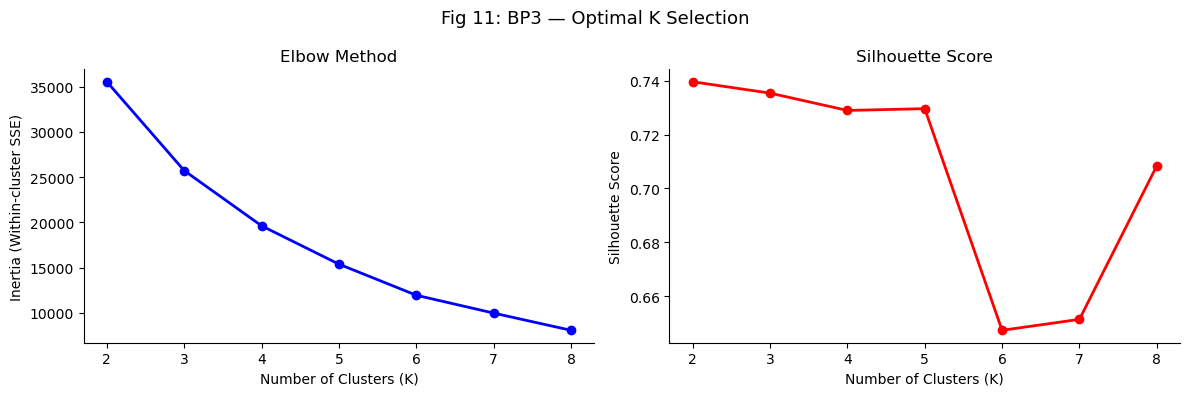

In [44]:
# --- Elbow + Silhouette plots ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Fig 11: BP3 — Optimal K Selection', fontsize=13)

axes[0].plot(list(K_range), inertia, 'bo-', linewidth=2, markersize=6)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (Within-cluster SSE)')
axes[0].set_title('Elbow Method')

axes[1].plot(list(K_range), silhouette_scores, 'ro-', linewidth=2, markersize=6)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')

plt.tight_layout()
plt.savefig('fig_kmeans_k.png', dpi=150, bbox_inches='tight')
plt.show()

#### Final K-Means Model (K=3)

In [34]:
# Remove the single extreme outlier row before clustering
outlier_mask = (df_clean['PumpHoursRoundUp'] == 484)
print(f"Removing {outlier_mask.sum()} extreme outlier row(s)")
df_clean = df_clean[~outlier_mask].reset_index(drop=True)

# Rebuild scaled cluster data without outlier
df_cluster = df_clean[cluster_features].copy()
df_cluster_scaled = pd.DataFrame(
    scaler.fit_transform(df_cluster),
    columns=cluster_features
)

# Refit K=3
BEST_K = 3
km_final = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
df_clean['Cluster'] = km_final.fit_predict(df_cluster_scaled)

print(f"\nCluster sizes after removing outlier:")
print(df_clean['Cluster'].value_counts().sort_index())

print(f"\n=== Cluster Statistics (original scale) ===")
cluster_stats = df_clean.groupby('Cluster')[cluster_features].agg(['mean','min','max']).round(2)
print(cluster_stats.to_string())

Removing 1 extreme outlier row(s)

Cluster sizes after removing outlier:
Cluster
0    11029
1      241
2      925
Name: count, dtype: int64

=== Cluster Statistics (original scale) ===
        NumPumpsAttending         PumpHoursRoundUp          Notional Cost (£)                NumCalls        
                     mean min max             mean min  max              mean    min     max     mean min max
Cluster                                                                                                      
0                    1.34   1   3             1.09   1    3            379.14  333.0  1092.0     1.24   1  13
1                    2.58   1   8             9.89   1  165           1957.71  333.0  2422.0     7.00   1  48
2                    3.73   1   8             2.55   1    6            890.66  333.0  2076.0     1.43   1  10


#### Cluster Composition Analysis

In [35]:
print("=== Cluster composition by IncidentGroup ===")
cluster_incident = pd.crosstab(df_clean['Cluster'],
                                df_clean['IncidentGroup'],
                                normalize='index').mul(100).round(1)
print(cluster_incident.to_string())

print("\n=== Cluster composition by Dwelling vs Non-Dwelling ===")
cluster_prop = pd.crosstab(df_clean['Cluster'],
                            df_clean['PropCat_Dwelling'],
                            normalize='index').mul(100).round(1)
cluster_prop.columns = ['Non-Dwelling %', 'Dwelling %']
print(cluster_prop.to_string())

print("\n=== Cluster composition by StopCodeDescription ===")
cluster_stop = pd.crosstab(df_clean['Cluster'],
                            df_clean['StopCodeDescription'],
                            normalize='index').mul(100).round(1)
print(cluster_stop.to_string())

=== Cluster composition by IncidentGroup ===
IncidentGroup  False Alarm  Fire  Special Service
Cluster                                          
0                     42.5  20.2             37.3
1                      1.7  90.5              7.9
2                     51.2  33.3             15.5

=== Cluster composition by Dwelling vs Non-Dwelling ===
         Non-Dwelling %  Dwelling %
Cluster                            
0                  51.2        48.8
1                  51.9        48.1
2                  30.7        69.3

=== Cluster composition by StopCodeDescription ===
StopCodeDescription   AFA  False alarm - Good intent  False alarm - Malicious  Primary Fire  Secondary Fire  Special Service
Cluster                                                                                                                     
0                    30.7                       10.7                      1.1           8.2            12.0             37.3
1                     0.8                

#### Correlation Analysis (Figure 15)

=== Pearson Correlation Matrix — Resource Variables ===
                   NumPumpsAttending  PumpHoursRoundUp  Notional Cost (£)  NumCalls
NumPumpsAttending              1.000             0.211              0.392     0.076
PumpHoursRoundUp               0.211             1.000              0.619     0.395
Notional Cost (£)              0.392             0.619              1.000     0.303
NumCalls                       0.076             0.395              0.303     1.000


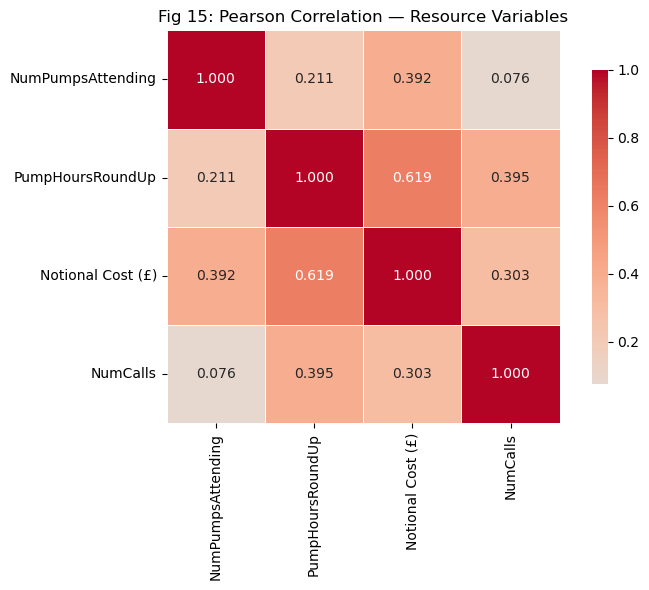

In [48]:
# --- Correlation analysis for BP3 ---
print("=== Pearson Correlation Matrix — Resource Variables ===")
corr_matrix = df_clean[cluster_features].corr().round(3)
print(corr_matrix.to_string())

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, ax=ax, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Fig 15: Pearson Correlation — Resource Variables')
plt.tight_layout()
plt.savefig('fig_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

#### Cluster Profile Visualisation (Figure 14)

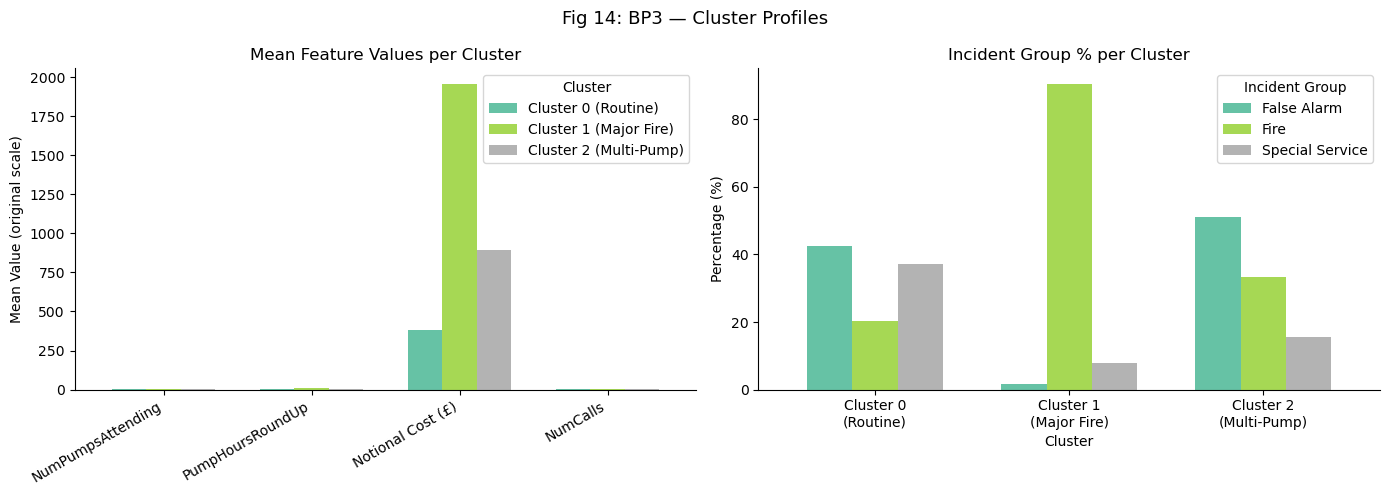

In [47]:
# --- Final cluster visualisation ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Fig 14: BP3 — Cluster Profiles', fontsize=13)

cluster_means = df_clean.groupby('Cluster')[cluster_features].mean()
cluster_means.T.plot(kind='bar', ax=axes[0], colormap='Set2', width=0.7)
axes[0].set_title('Mean Feature Values per Cluster')
axes[0].set_ylabel('Mean Value (original scale)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
axes[0].legend(title='Cluster', labels=['Cluster 0 (Routine)', 'Cluster 1 (Major Fire)', 'Cluster 2 (Multi-Pump)'])

cluster_incident.plot(kind='bar', ax=axes[1], colormap='Set2', width=0.7)
axes[1].set_title('Incident Group % per Cluster')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xticklabels(['Cluster 0\n(Routine)', 'Cluster 1\n(Major Fire)', 'Cluster 2\n(Multi-Pump)'], rotation=0)
axes[1].legend(title='Incident Group')

plt.tight_layout()
plt.savefig('fig_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 📋 Section 10 — Model Evaluation (Task 5)

### IF-THEN Rules — BP1 Decision Tree

In [38]:
# =============================================================
# TASK 5 — Model Evaluation
# 5.3 Decision Tree IF-THEN Rules (BP1)
# =============================================================

from sklearn.tree import export_text

print("=== BP1: Decision Tree Rules ===")
rules_bp1 = export_text(dt_bp1, feature_names=bp1_features, max_depth=3)
print(rules_bp1)

=== BP1: Decision Tree Rules ===
|--- PropCat_Non Residential <= 0.50
|   |--- PropCat_Dwelling <= 0.50
|   |   |--- PropCat_Other Residential <= 0.50
|   |   |   |--- PropCat_Road Vehicle <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- PropCat_Road Vehicle >  0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- PropCat_Other Residential >  0.50
|   |   |   |--- CalYear <= 2020.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- CalYear >  2020.50
|   |   |   |   |--- truncated branch of depth 2
|   |--- PropCat_Dwelling >  0.50
|   |   |--- NumCalls <= 3.50
|   |   |   |--- CalYear <= 2020.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- CalYear >  2020.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- NumCalls >  3.50
|   |   |   |--- class: 1
|--- PropCat_Non Residential >  0.50
|   |--- NumCalls <= 2.50
|   |   |--- HourOfCall <= 13.50
|   |   |   |--- DayOfWeek_num <= 4.50
|   |   |   |   |

### IF-THEN Rules — BP2 Decision Tree Regressor

In [39]:
# =============================================================
# 5.3 Decision Tree IF-THEN Rules (BP2)
# =============================================================

print("=== BP2: Decision Tree Regressor Rules ===")
rules_bp2 = export_text(dt_bp2, feature_names=bp2_features, max_depth=3)
print(rules_bp2)

=== BP2: Decision Tree Regressor Rules ===
|--- NumPumpsAttending <= 1.50
|   |--- PropCat_Non Residential <= 0.50
|   |   |--- HourOfCall <= 7.50
|   |   |   |--- HourOfCall <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- HourOfCall >  0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- HourOfCall >  7.50
|   |   |   |--- NumCalls <= 1.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- NumCalls >  1.50
|   |   |   |   |--- truncated branch of depth 2
|   |--- PropCat_Non Residential >  0.50
|   |   |--- HourOfCall <= 18.50
|   |   |   |--- HourOfCall <= 10.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- HourOfCall >  10.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- HourOfCall >  18.50
|   |   |   |--- HourOfCall <= 20.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- HourOfCall >  20.50
|   |   |   |   |--- truncated branch of depth 2
|--- NumPumpsAttending >  1.50
|  

### Model Comparison Summary

In [40]:
# =============================================================
# 5.2 Model Comparison Summary
# =============================================================

print("=== BP1: Classification Model Comparison ===")
print(f"{'Model':<25} {'Train Acc':>10} {'Test Acc':>10} {'Gap':>8}")
print("-" * 55)
print(f"{'Decision Tree':<25} {dt_bp1.score(X_train_bp1, y_train_bp1):>10.4f} "
      f"{accuracy_score(y_test_bp1, y_pred_dt_bp1):>10.4f} "
      f"{dt_bp1.score(X_train_bp1, y_train_bp1) - accuracy_score(y_test_bp1, y_pred_dt_bp1):>8.4f}")
print(f"{'Logistic Regression':<25} {lr_bp1.score(X_train_bp1, y_train_bp1):>10.4f} "
      f"{accuracy_score(y_test_bp1, y_pred_lr_bp1):>10.4f} "
      f"{lr_bp1.score(X_train_bp1, y_train_bp1) - accuracy_score(y_test_bp1, y_pred_lr_bp1):>8.4f}")

print(f"\n=== BP2: Regression Model Comparison ===")
print(f"{'Model':<25} {'Train R²':>10} {'Test R²':>10} {'MAE':>10} {'RMSE':>10}")
print("-" * 70)
print(f"{'Decision Tree':<25} {dt_bp2.score(X_train_bp2, y_train_bp2):>10.4f} "
      f"{r2_score(y_test_bp2, y_pred_dt_bp2):>10.4f} "
      f"{mean_absolute_error(y_test_bp2, y_pred_dt_bp2):>10.2f} "
      f"{mean_squared_error(y_test_bp2, y_pred_dt_bp2, squared=False):>10.2f}")
print(f"{'Linear Regression':<25} {lr_bp2.score(X_train_bp2, y_train_bp2):>10.4f} "
      f"{r2_score(y_test_bp2, y_pred_lr_bp2):>10.4f} "
      f"{mean_absolute_error(y_test_bp2, y_pred_lr_bp2):>10.2f} "
      f"{mean_squared_error(y_test_bp2, y_pred_lr_bp2, squared=False):>10.2f}")

=== BP1: Classification Model Comparison ===
Model                      Train Acc   Test Acc      Gap
-------------------------------------------------------
Decision Tree                 0.6238     0.5852   0.0386
Logistic Regression           0.6073     0.5762   0.0311

=== BP2: Regression Model Comparison ===
Model                       Train R²    Test R²        MAE       RMSE
----------------------------------------------------------------------
Decision Tree                 0.0424     0.0278      88.88     113.59
Linear Regression             0.0286     0.0246      89.45     113.77


---

## ✅ Analysis Complete

> All models built and evaluated. See the full report for interpretation and recommendations.